In [1]:
import os

if 'OPENAI_API_KEY' in os.environ:
  del os.environ['OPENAI_API_KEY']

In [2]:
# 명시적 경로로 재로드
from dotenv import load_dotenv
load_dotenv(r"c:\Users\Admin\hipython\llm\.env", override=True)

True

In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

OPENAI_API_KEY = os.environ['OPENAI_API_KEY']
#PINECONE_API_KEY = os.environ['PINECONE_API_KEY']

print("API 키 로드 완료")
print(f"OpenAI Key: {OPENAI_API_KEY[:10]}...")

API 키 로드 완료
OpenAI Key: sk-proj-00...


In [4]:
# Step 2 : LCEL 기본 체인 동작 확인
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [5]:
llm = ChatOpenAI(model="gpt-4o-mini")
prompt = PromptTemplate.from_template("{topic}에 대해 한 문장으로 설명해줘")
output_parsers = StrOutputParser()

prompt > LLM(ChatOpenAI) > output_parsers

In [6]:
chain = prompt | llm | output_parsers

In [7]:
result = chain.invoke({"topic": "RAG"})
print(result)

RAG(Recall-Augmented Generation)는 정보 검색과 자연어 생성을 결합하여, 주어진 질문에 대한 응답을 생성할 때 외부 데이터베이스에서 관련 정보를 찾아 활용하는 모델입니다.


In [8]:
import langchain
print(langchain.__version__)

1.2.15


In [9]:
messages = [
    ("system", "당신은 손목이 얇은 시계 애호가입니다."),
    ("human", "러그 길이가 적당한 다이버 워치 5개를 추천해주세요") 
]

response = llm.invoke(messages)
print(response.content)

얇은 손목을 가진 시계 애호가로서 러그 길이가 적당한 다이버 워치를 찾는 것은 매우 중요합니다. 다음은 러그 길이가 적절하고 다이버 기능을 갖춘 5가지 추천 시계입니다.

1. **Seiko Prospex Diver's SRPD**  
   - 러그 길이: 약 46mm  
   - 직경: 44mm  
   - 이 시계는 Seiko의 전통적인 다이버 디자인을 가지고 있으며, 자동 무브먼트와 다이브 기능을 갖춘 신뢰성 있는 모델입니다.

2. **Tudor Black Bay Fifty-Eight**  
   - 러그 길이: 약 47.5mm  
   - 직경: 39mm  
   - 클래식한 디자인과 현대적인 기술이 결합된 이 시계는 심플하면서도 세련된 느낌을 줍니다.

3. **Omega Seamaster Professional 300M**  
   - 러그 길이: 약 50mm  
   - 직경: 42mm  
   - 오메가의 인기 모델인 Seamaster는 뛰어난 방수 성능과 견고한 디자인으로 유명합니다.

4. **Tag Heuer Aquaracer 300M**  
   - 러그 길이: 약 47mm  
   - 직경: 43mm  
   - Aquaracer는 세련된 스타일과 스포츠 기능성을 잘 결합한 모델로, 다양한 환경에서 사용할 수 있습니다.

5. **Longines HydroConquest**  
   - 러그 길이: 약 48mm  
   - 직경: 41mm  
   - 이 시계는 세련된 디자인과 높은 품질의 소재로 만들어져 있으며, 다이버로서의 기능도 충분히 갖추고 있습니다.

이 모델들은 러그 길이와 다이브 기능 모두에서 만족스러운 선택이 될 것입니다. 각 모델의 세부 사항을 확인하고, 본인의 취향에 맞는 시계를 선택해 보세요!


In [10]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain.agents import create_agent   # LangChain 1.x
from langgraph.prebuilt import create_react_agent


In [11]:
# 1. 도구 정의
@tool
def add(a: float, b: float) -> float:
    """두 숫자를 더합니다."""
    return a + b

In [12]:
@tool
def multiply(a: float, b: float) -> float:
    """두 숫자를 곱합니다."""
    return a * b

In [13]:
tools = [add, multiply]

In [14]:
# 2. 에이전트 생성
agent = create_react_agent(
    model=llm,
    tools=tools,
    prompt="당신은 계산을 도와주는 어시스턴트입니다.")


C:\Users\Admin\AppData\Local\Temp\ipykernel_16172\418765619.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


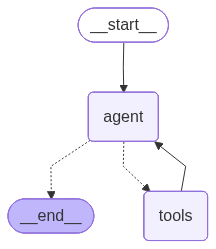

In [15]:
agent

In [16]:
# 3. 실행
result = agent.invoke({
    "messages": [{"role": "user", "content": "3 더하기 5는 얼마야? 그리고 그 결과에 7을 곱하면?"}]
})

print(result["messages"][-1].content)

3 더하기 5는 8입니다. 그리고 그 결과인 8에 7을 곱하면 56이 됩니다.


In [17]:
for msg in result['messages']:
  print(msg.content)

3 더하기 5는 얼마야? 그리고 그 결과에 7을 곱하면?

8.0
56.0
3 더하기 5는 8입니다. 그리고 그 결과인 8에 7을 곱하면 56이 됩니다.


In [18]:
for msg in result["messages"]:
    print(f"[{msg.__class__.__name__}] {msg.content[:80] if msg.content else '(tool call)'}")

[HumanMessage] 3 더하기 5는 얼마야? 그리고 그 결과에 7을 곱하면?
[AIMessage] (tool call)
[ToolMessage] 8.0
[ToolMessage] 56.0
[AIMessage] 3 더하기 5는 8입니다. 그리고 그 결과인 8에 7을 곱하면 56이 됩니다.


In [ ]:
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_tavily import TavilySearch       # langchain-tavily 패키지
from langchain.agents import create_agent
import ast
import operator

In [ ]:
# 1. 도구 정의: 웹 검색
search_tool = TavilySearch(max_results=3)

In [ ]:
# 2. 도구 정의: 안전한 계산기
SAFE_OPERATORS = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.Pow: operator.pow,
}

def _safe_eval(node):
    if isinstance(node, ast.Constant):
        return node.value
    elif isinstance(node, ast.BinOp):
        op = SAFE_OPERATORS.get(type(node.op))
        if op is None:
            raise ValueError(f"지원하지 않는 연산자: {node.op}")
        return op(_safe_eval(node.left), _safe_eval(node.right))
    raise ValueError(f"허용되지 않는 표현식: {node}")

@tool
def calculate(expression: str) -> str:
    """사칙연산과 거듭제곱만 허용하는 안전한 계산기입니다. 예: '1234 * 5678'"""
    try:
        tree = ast.parse(expression, mode="eval")
        result = _safe_eval(tree.body)
        return str(result)
    except Exception as e:
        return f"계산 오류: {e}"

In [26]:
# 3. 에이전트 생성
from langgraph.prebuilt import create_react_agent

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

agent = create_react_agent(
    model=llm,
    tools=[search_tool, calculate],
    prompt="""당신은 웹 검색과 계산을 도와주는 AI 어시스턴트입니다.

규칙:
- 동일하거나 유사한 검색 쿼리를 반복하지 마세요.
- 검색 결과가 없으면 즉시 그 사실을 사용자에게 알리세요.
- 최대 3번 검색 후 반드시 최종 답변을 제공하세요."""
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_16172\3948064598.py:6: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


In [27]:
# 4. 테스트 실행
print("=== 테스트 1: 검색만 사용 ===")
result1 = agent.invoke({
    "messages": [{"role": "user", "content": "2024년 한국 GDP는 얼마야?"}]
})
print(result1["messages"][-1].content)

print("\n=== 테스트 2: 계산기만 사용 ===")
result2 = agent.invoke({
    "messages": [{"role": "user", "content": "1234 곱하기 5678은 얼마야?"}]
})
print(result2["messages"][-1].content)

print("\n=== 테스트 3: 검색 + 계산기 모두 사용 ===")
result3 = agent.invoke({
    "messages": [{"role": "user", "content": "2024년 한국 GDP를 검색하고, 그 금액을 1300으로 나누면 얼마야?"}]
})
print(result3["messages"][-1].content)

=== 테스트 1: 검색만 사용 ===
2024년 한국의 GDP는 약 1.87조 달러(1,875,388 백만 달러)로 예상됩니다. 이는 한국 경제가 세계에서 13번째로 큰 규모임을 나타냅니다. 또한, 1인당 GDP는 약 36,024 달러로 추정되고 있습니다. 

더 자세한 정보는 [여기](https://www.kedglobal.com/economy/newsView/ked202501230002)에서 확인하실 수 있습니다.

=== 테스트 2: 계산기만 사용 ===
1234 곱하기 5678은 7,006,652입니다.

=== 테스트 3: 검색 + 계산기 모두 사용 ===
2024년 한국의 GDP는 약 1.9 조 달러(1,875,388 백만 달러)입니다. 이 금액을 1300으로 나누면 약 1442.31입니다.


In [28]:
# result3 = agent.invoke({
#     "messages": [{"role": "user", "content": "2024년 한국 GDP를 검색하고, 그 금액을 1300으로 나누면 얼마야?"}]
# })

for msg in result3["messages"]:
    name = msg.__class__.__name__
    # 툴 호출 정보 추출
    tool_calls = getattr(msg, "tool_calls", [])
    if tool_calls:
        for tc in tool_calls:
            print(f"[{name}] 도구 호출: {tc['name']}({tc['args']})")
    else:
        content = str(msg.content)[:120] if msg.content else ""
        print(f"[{name}] {content}")

[HumanMessage] 2024년 한국 GDP를 검색하고, 그 금액을 1300으로 나누면 얼마야?
[AIMessage] 도구 호출: tavily_search({'query': '2024 South Korea GDP'})
[ToolMessage] {"query": "2024 South Korea GDP", "response_time": 0.63, "follow_up_questions": null, "answer": null, "images": [], "res
[AIMessage] 도구 호출: calculate({'expression': '1875000/1300'})
[ToolMessage] 1442.3076923076924
[AIMessage] 2024년 한국의 GDP는 약 1.9 조 달러(1,875,388 백만 달러)입니다. 이 금액을 1300으로 나누면 약 1442.31입니다.


In [29]:
for step in agent.stream(
    {"messages": [{"role": "user", "content": "2024년 한국 GDP를 검색하고, 그 금액을 1300으로 나누면 얼마야?"}]},
    stream_mode="updates",   # 각 노드 업데이트마다 출력
):
    for node_name, node_output in step.items():
        print(f"\n{'='*40}")
        print(f"노드: {node_name}")
        for msg in node_output.get("messages", []):
            name = msg.__class__.__name__
            tool_calls = getattr(msg, "tool_calls", [])
            if tool_calls:
                for tc in tool_calls:
                    print(f"  도구 호출: {tc['name']}({tc['args']})")
            else:
                print(f"  [{name}] {str(msg.content)[:120]}")


노드: agent
  도구 호출: tavily_search({'query': '2024 South Korea GDP'})

노드: tools
  [ToolMessage] {"query": "2024 South Korea GDP", "response_time": 0.63, "follow_up_questions": null, "answer": null, "images": [], "res

노드: agent
  도구 호출: calculate({'expression': '1875000000/1300'})

노드: tools
  [ToolMessage] 1442307.6923076923

노드: agent
  [AIMessage] 2024년 한국의 GDP는 약 1.9 조 달러(1,875,388 백만 달러)입니다. 이 금액을 1300으로 나누면 약 1,442,308이 됩니다.
